# Phase Oscillator
**WARNING!** This notebook creates audio that you can play through your speakers or headphones. Be careful--the sound might get very loud, and loud sounds can damage your hearing. If you're using headphones, it's best to turn the volume down very low at first, until you know how loud the sound will actually be.

The phase oscillator here works on the same principle as the example in the ECE 402 slides. But because we're implementing it in Python with NumPy, it's a little different. For one thing, we don't have 24-bit numbers in NumPy.

First, we're going to set up the wavetable. It contains one period of a sine wave.

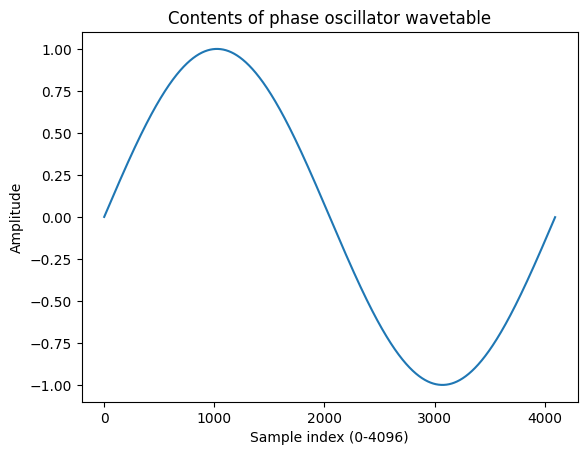

In [37]:
import numpy as np
import matplotlib.pyplot as plt

# The wavetable will have 4096 samples as shown in the slides. We will fill it with one period of a sine wave.
WAVETABLE_SIZE = 4096
wavetable = np.sin(np.linspace(0, 2*np.pi*WAVETABLE_SIZE/(WAVETABLE_SIZE+1), WAVETABLE_SIZE))

fig, ax = plt.subplots()
ax.plot(wavetable)
ax.set_title("Contents of phase oscillator wavetable")
ax.set_ylabel("Amplitude")
ax.set_xlabel("Sample index (0-4096)")
plt.show()

Now we need to set up the generator sampling rate and the oscillator frequency. We keep the sample rate constant--a typical sample rate would be 44.1 or 48 kHz. Here, we use 48 kHz.

The oscillator frequency determines the contents of the frequency register and therefore the pitch of the output sound. The contents of the frequency register and phase register are fractional--the frequency register value is constant, $f/f_s$.

In [38]:
generator_fs = 48000
osc_freq = 440.0

# Freq register and phase register will be 64-bit fractional. Phase register is initialized to 0.
freq_register = np.float64(osc_freq/generator_fs)
phase_register = np.float64(0)

Now we're ready to generate sound. We'll produce 2 seconds of output audio.

In [39]:
# Initialize empty output array of 1 second duration
duration = 2.0
output = np.zeros((int(generator_fs*duration)), dtype=np.float64)

# Fill in each sample for 1 second of audio
for i in range(1, output.shape[-1]):
    # The fmod operation simulates what happens when the fractional register reaches 1.0 and wraps around.
    phase_register = np.fmod(phase_register + freq_register, 1.0)

    # This is analogous to taking the top 12 bits of the phase register.
    index = int(np.floor(phase_register * WAVETABLE_SIZE))
    
    output[i] = wavetable[index]

Now that we've filled an array with output audio, we want to play it. We could write it to a WAV audio file using the `soundfile` or `pedalboard` libraries. Here, we'll just make an audio player directly.

In [40]:
# Sound player courtesy of Minje Kim in UIUC CS department
def sound_player( x, rate=8000, label=''):
    from IPython.display import display, Audio, HTML
    display( HTML( 
    '<style> table, th, td {border: 0px; }</style> <table><tr><td>' + label + 
    '</td><td>' + Audio( x, rate=rate)._repr_html_()[3:] + '</td></tr></table>'
    ))

sound_player(output, generator_fs, "Phase oscillator output")

Phase oscillator output,Your browser does not support the audio element.


We can plot the output of the phase oscillator. Notice that the sample indices have changed relative to the wavetable, since we're playing back at a different frequency.

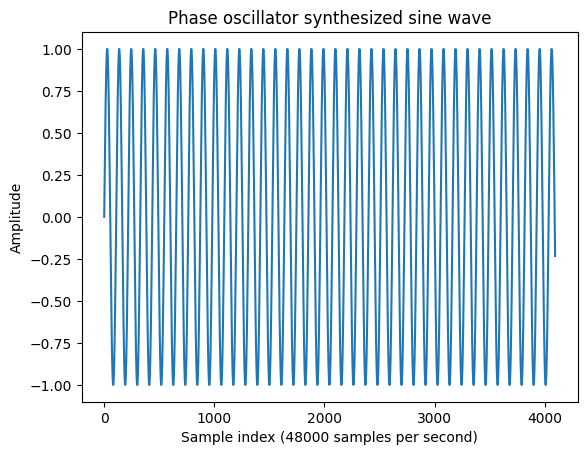

In [41]:
fig, ax = plt.subplots()
ax.plot(output[:4096])
ax.set_title("Phase oscillator synthesized sine wave")
ax.set_ylabel("Amplitude")
ax.set_xlabel("Sample index (48000 samples per second)")
plt.show()

We notice that there's an annoying click at the end where the waveform stops without returning to 0.0. We can fix this.

In [42]:
output[-1024:] *= np.linspace(1.0, 0.0, 1024)
sound_player(output, generator_fs, "Adjusted phase oscillator output")

Adjusted phase oscillator output,Your browser does not support the audio element.


You might want to experiment with filling the wavetable with something other than a sine wave.

**WARNING!** If you do this, be careful to keep the values in the wavetable between -1.0 and 1.0. And always start with the volume at a low level for safety. Remember, loud sounds can damage your hearing!